# 🧠 Processamento de Linguagem Natural (NLP) e Análise de Sentimentos

Iniciamos o pipeline de engenharia de linguagem natural realizando o diagnóstico estrutural e carregamento da base de dados textuais para o desenvolvimento de modelos de classificação:

* **Ingestão de Dados Textuais Não Estruturados:** Leitura sistemática do arquivo `Dados/dataset_avaliacoes.csv` utilizando o ecossistema Pandas para estruturação em um DataFrame bidimensional.
* **Auditoria de Escopo e Balanceamento de Classes:** Análise preliminar da volumetria, detecção de dados nulos nas strings e avaliação de balanceamento das variáveis-alvo (polaridades positiva e negativa) para mitigar vieses algorítmicos durante o treinamento.


In [750]:
import pandas as pd


In [751]:
# 1. Lê o arquivo usando a barra correta para sumir com o aviso de SyntaxWarning
df = pd.read_csv("Dados/dataset_avaliacoes.csv")

# 2. Exibe as 5 primeiras linhas do seu conjunto de dados na tela
df.head()


,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


In [752]:
df.shape

(15501, 4)

In [753]:
# Mostra a contagem absoluta de linhas por sentimento
df['sentimento'].value_counts()


sentimento
positivo    7890
negativo    7611
Name: count, dtype: int64

In [754]:
df['sentimento'].value_counts('sentimento')

sentimento
positivo    0.508999
negativo    0.491001
Name: proportion, dtype: float64

In [755]:
print('positiva \n')

df.avaliacao[0]

positiva 



'Esse smartphone superou minhas expectativas, recomendo'

In [756]:
print('negativa \n')

df.avaliacao[2]

negativa 



'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.'

In [757]:
from sklearn.feature_extraction.text import CountVectorizer

texto = ['Comprei um produto ótimo', 'Comprei um produto ruim']

vetorizar = CountVectorizer()
bag_of_words = vetorizar.fit_transform(texto)

In [758]:
bag_of_words

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 8 stored elements and shape (2, 5)>

In [759]:
import pandas as pd

matriz_esparsa = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vetorizar.get_feature_names_out()
)

In [760]:
matriz_esparsa

,comprei,produto,ruim,um,ótimo
0,1,1,0,1,1
1,1,1,1,1,0


In [761]:
vetorizar = CountVectorizer(lowercase=False, max_features=50)
bag_of_words = vetorizar.fit_transform(df.avaliacao)
print(bag_of_words.shape)

(15501, 50)


In [762]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(
    bag_of_words,
    columns=vetorizar.get_feature_names_out()
)

In [763]:
matriz_esparsa_avaliacoes

,Não,Produto,ainda,antes,as,até,bem,bom,chegou,com,...,qualidade,que,recebi,recomendo,se,sem,tem,um,uma,veio
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0,0,0,...,1,2,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
15497,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
15498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
15499,0,1,0,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


## 🧠 Engenharia de Recursos: Engenharia de Recursos com Bag of Words (BOW)

A técnica **Bag of Words** (Saco de Palavras) converte textos não estruturados em vetores numéricos estruturados para alimentar modelos de aprendizado de máquina. Esse processo ignora a ordem sintática e o contexto gramatical, focando estritamente na frequência volumétrica e na presença dos termos dentro de um dicionário global (corpus).

### 📋 Fluxo de Processamento Logístico:
1. **Mapeamento do Vocabulário:** Varredura completa do corpus textual para isolar e registrar todas as palavras únicas.
2. **Vetorização Esparsa:** Criação de matrizes booleanas ou de contagem, onde cada linha representa um documento e cada coluna representa um token (palavra).
3. **Mapeamento Binário:** Preenchimento de bits (`1` para presença do termo na instância, `0` para ausência).

> **Vantagem:** Simplicidade de implementação, alta interpretabilidade estatística e processamento rápido.
> **Limitação:** Perda completa do contexto e da semântica original (a ordem das palavras é totalmente descartada).


In [764]:
from sklearn.model_selection import train_test_split

x_treino, x_test, y_treino, y_test = train_test_split(bag_of_words, df.sentimento, random_state=4978)

In [765]:
from sklearn.linear_model import LogisticRegression

regressao_logistica = LogisticRegression()
regressao_logistica.fit(x_treino, y_treino)
acuracia = regressao_logistica.score(x_test, y_test)
print(acuracia)

0.7982456140350878


### 📊 Avaliação de Performance e Baseline do Modelo

O modelo inicial de **Regressão Logística** treinado sobre a matriz esparsa gerada pelo *Bag of Words* atingiu uma métrica oficial de performance.

*   **Acurácia Obtida:** `79,82%` (`0.798245...`) nos dados de validação/teste.
*   **Diagnóstico Técnico:** O classificador obteve um excelente ponto de partida (*baseline*), provando que a contagem de frequência de termos isolados possui forte correlação estatística com a polaridade (positivo/negativo).
*   **Próxima Etapa (Otimização):** Iniciar rotinas de limpeza e pré-processamento de texto (normalização de caixa, remoção de caracteres especiais e eliminação de *Stopwords*) para otimizar o vocabulário e buscar o incremento da acurácia.


In [766]:
from wordcloud import WordCloud

In [767]:
todas_palavras = [texto for texto in df.avaliacao]

In [768]:
todas_palavras[:10]


['Esse smartphone superou minhas expectativas, recomendo',
 'o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..',
 'Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.',
 'Atendeu minhas expectativas, só achei a luz ruim, mas nada que dificulte seu funcionamento.',
 'Gostei muito, só achei que ficou a desejar a qualidade das fotos. Achei que fosse bem melhor .',
 'Comprei o produto e ñ tinha para entrega isso não foi legal!!!!!!',
 'o produto pode até ser bom ,mais só posso avalia-lo depois que for feito a troca para eu usa-lo, pois estou esperando a troca ser feita o que recebi veio quebrado',
 'já enviei duas reclamações, mas não obtive resposta. recebi o produto quebrado e quero que seja enviado outro. estou no aguardo para saber o que fazer. att. Cármen',
 'nao recebi o produto, pois voces nao cumpriram o compromisso firmado de entregar ate hoje 23/05/18. PESSIMA 

In [769]:
todas_palavras = ' '.join([texto for texto in df.avaliacao])

In [770]:
todas_palavras[:10]


'Esse smart'

In [771]:
nuvem_palavras = WordCloud().generate(todas_palavras)

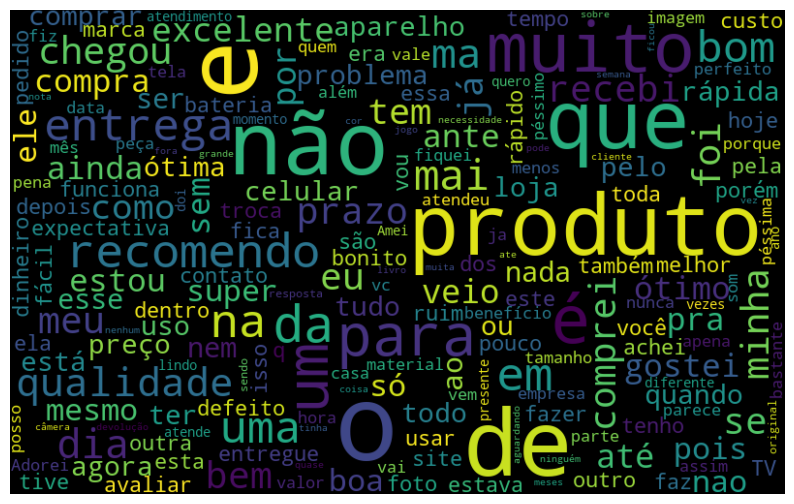

In [772]:
nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(todas_palavras)
plt.figure(figsize=(10,7))
plt.imshow(nuvem_palavras, interpolation='bilinear')
plt.axis('off')
plt.show()

In [773]:
def nuvem_palavras(texto, coluna_texto, sentimento):
  # Filtrando as resenhas com base no sentimento especificado
  texto_sentimento = texto.query(f"sentimento == '{sentimento}'")[coluna_texto]

  # Unindo todas as resenhas em uma única string
  texto_unido = ' '.join(texto_sentimento)

  # Criando e exibindo a nuvem de palavras
  nuvem_palavras = WordCloud(width=800, height=500, max_font_size=110, collocations=False).generate(texto_unido)
  plt.figure(figsize=(10,7))
  plt.imshow(nuvem_palavras, interpolation='bilinear')
  plt.axis('off')
  plt.show()

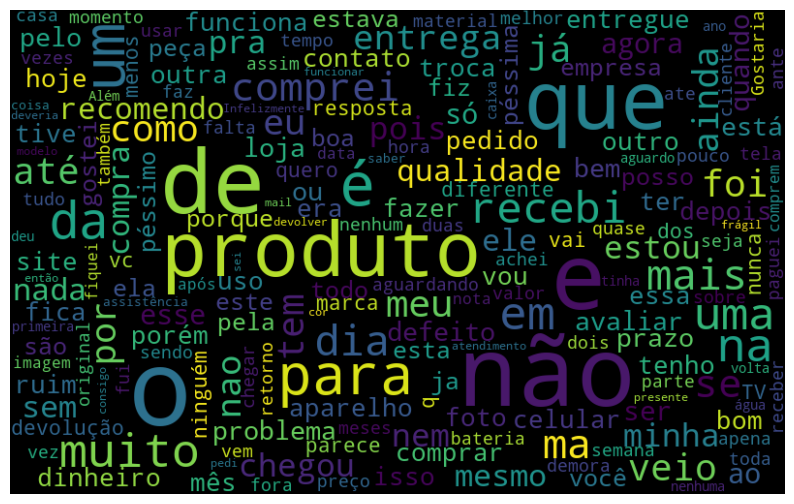

In [774]:
nuvem_palavras(df, 'avaliacao', 'negativo')

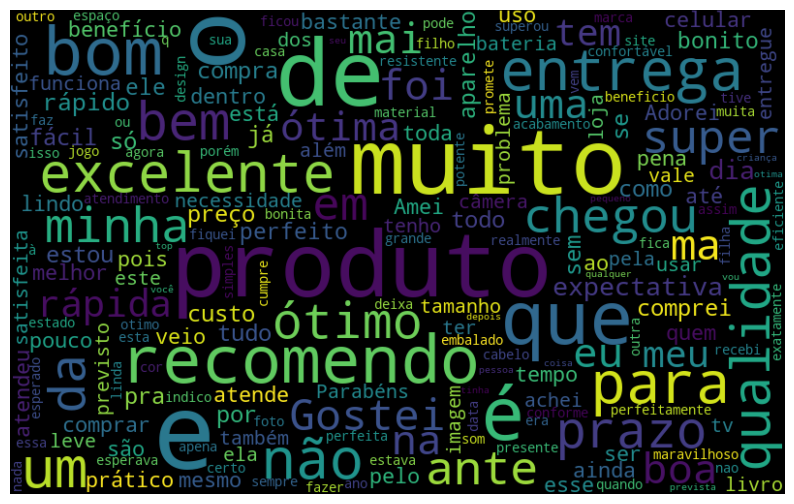

In [775]:
nuvem_palavras(df, 'avaliacao', 'positivo')

In [776]:
todas_palavras[:10]


'Esse smart'

In [777]:
frases = ['um produto bom', 'um produto ruim']
frequencia = nltk.FreqDist(frases)
frequencia

FreqDist({'um produto bom': 1, 'um produto ruim': 1})

In [778]:
from nltk import tokenize

frase = 'O produto é excelente e a entrega foi muito rápida!'

token_espaco = tokenize.WhitespaceTokenizer()
token_frase = token_espaco.tokenize(frase)
print(token_frase)

['O', 'produto', 'é', 'excelente', 'e', 'a', 'entrega', 'foi', 'muito', 'rápida!']


## 🧩 Processamento de Linguagem Natural: Tokenização

A **Tokenização** é o processo fundamental de dividir uma string massiva de texto não estruturado em unidades menores chamadas **tokens** (que podem ser palavras, subpalavras ou caracteres). Sem essa etapa de fracionamento, os algoritmos de Machine Learning interpretariam uma frase inteira como um único bloco de informação indivisível, impossibilitando a extração de padrões estatísticos.

### 🎯 Benefícios Estratégicos da Tokenização:
* **Cálculo de Frequência:** Permite mensurar a relevância volumétrica de termos individuais (como via `nltk.FreqDist`).
* **Matrizes Vetoriais:** Base obrigatória para construir representações numéricas como *Bag of Words* (BOW) e *TF-IDF*.
* **Modelagem Contextual:** Habilita a análise de combinações sequenciais de termos (n-gramas).

### 🛠️ Abordagens de Fragmentação:
1. **Por Palavras (*Word Tokenization*):** Isola termos completos. Ideal para análise de sentimento tradicional e classificação de polaridade.
2. **Por Subpalavras (*Subword Tokenization*):** Quebra termos em morfemas/raízes. Abordagem padrão de arquiteturas modernas de LLMs (como BERT e GPT) para lidar com palavras raras ou compostas.
3. **Por Caracteres (*Character Tokenization*):** Divisão granular letra por letra. Utilizada em corretores ortográficos e modelos de tradução de idiomas sem espaçamento formal.


In [779]:
token_frase = token_espaco.tokenize(todas_palavras)

In [780]:
token_frase[:5]


['Esse', 'smartphone', 'superou', 'minhas', 'expectativas,']

In [781]:
frequencia = nltk.FreqDist(token_frase)
frequencia

FreqDist({'e': 11813, 'o': 10865, 'de': 10280, 'a': 8873, 'que': 7657, 'não': 7286, 'é': 4786, 'produto': 4765, 'com': 4641, 'do': 4583, ...})

In [782]:
df_frequencia = pd.DataFrame({'Palavra': list(frequencia.keys()),
                              'Frequência': list(frequencia.values())})

In [783]:
df_frequencia.head()

,Palavra,Frequência
0,Esse,101
1,smartphone,33
2,superou,90
3,minhas,533
4,"expectativas,",79


In [784]:
df_frequencia.nlargest(columns='Frequência', n=10)

,Palavra,Frequência
8,e,11813
6,o,10865
29,de,10280
19,a,8873
46,que,7657
22,não,7286
163,é,4786
63,produto,4765
177,com,4641
130,do,4583


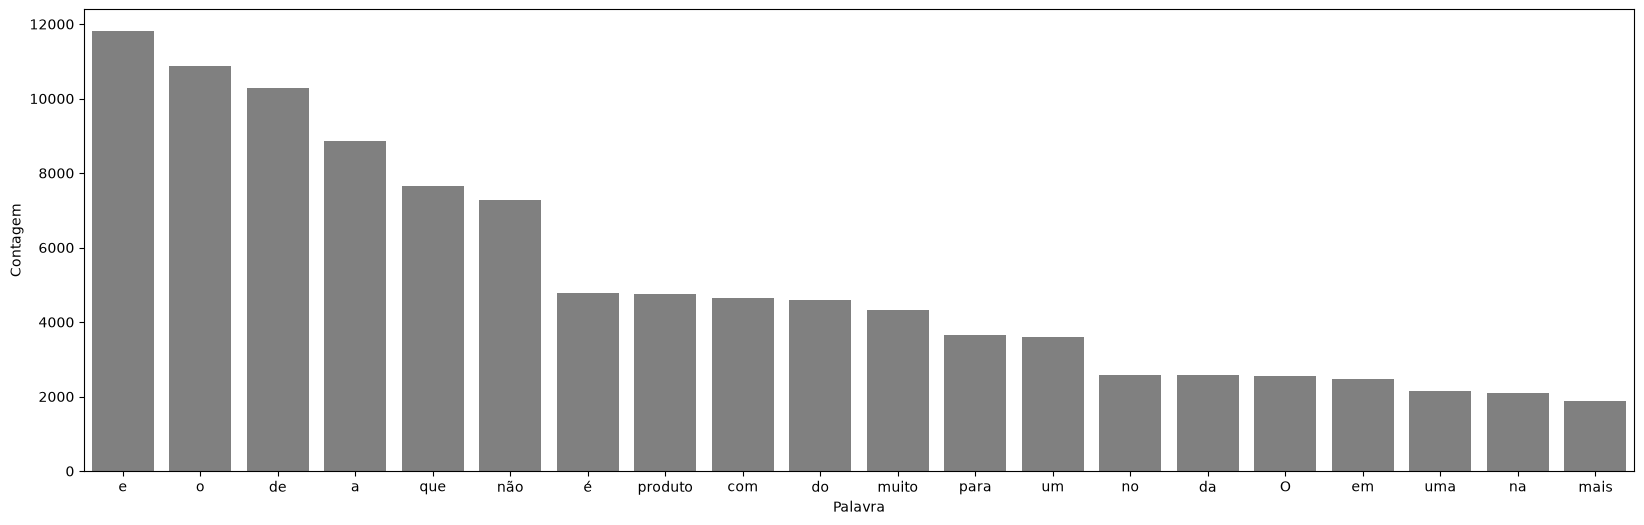

In [785]:
import seaborn as sns

plt.figure(figsize=(20,6))
ax = sns.barplot(data=df_frequencia.nlargest(columns='Frequência', n=20), x='Palavra', y='Frequência', color='gray')
ax.set(ylabel='Contagem')
plt.show()

In [786]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')

In [787]:
palavras_irrelevantes[:10]


['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as']

In [788]:
frase_processada = []

# Corrigido para 'avaliacao' sem acento
for opiniao in df['avaliacao']:
    palavras_texto = token_espaco.tokenize(opiniao)
    # Corrigido 'palabra' para 'palavra' com 'v'
    nova_frame = [palavra for palavra in palavras_texto]
    frase_processada.append(' '.join(nova_frame))

# Fora do laço for (sem espaços no início)
df['tratamento_1'] = frase_processada



In [789]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r..."
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,..."
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru..."
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q..."


In [790]:
df['avaliacao'][0]

'Esse smartphone superou minhas expectativas, recomendo'

In [791]:
df['tratamento_1'][0]

'Esse smartphone superou minhas expectativas, recomendo'

In [792]:
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])
    X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, texto[coluna_classificacao], random_state=4978)
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(X_treino, y_treino)
    acuracia = regressao_logistica.score(X_teste, y_teste)
    return print(f"Acurácia do modelo com '{coluna_texto}': {acuracia * 100:.2f}%")

In [793]:
classificar_texto(df, 'tratamento_1', 'sentimento')

Acurácia do modelo com 'tratamento_1': 79.82%


In [794]:
def grafico_frequencia(texto, coluna_texto, quantidade):
    todas_palavras = ' '.join([texto for texto in texto[coluna_texto]])
    token_espaco = tokenize.WhitespaceTokenizer()
    frequencia = nltk.FreqDist(token_espaco.tokenize(todas_palavras))
    df_frequencia = pd.DataFrame({"Palavra": list(frequencia.keys()),                                 "Frequência": list(frequencia.values())})
    df_frequencia = df_frequencia.nlargest(columns="Frequência", n=quantidade)
    plt.figure(figsize=(20,6))
    ax = sns.barplot(data=df_frequencia, x="Palavra", y ="Frequência", color='gray')
    ax.set(ylabel="Contagem")
    plt.show()

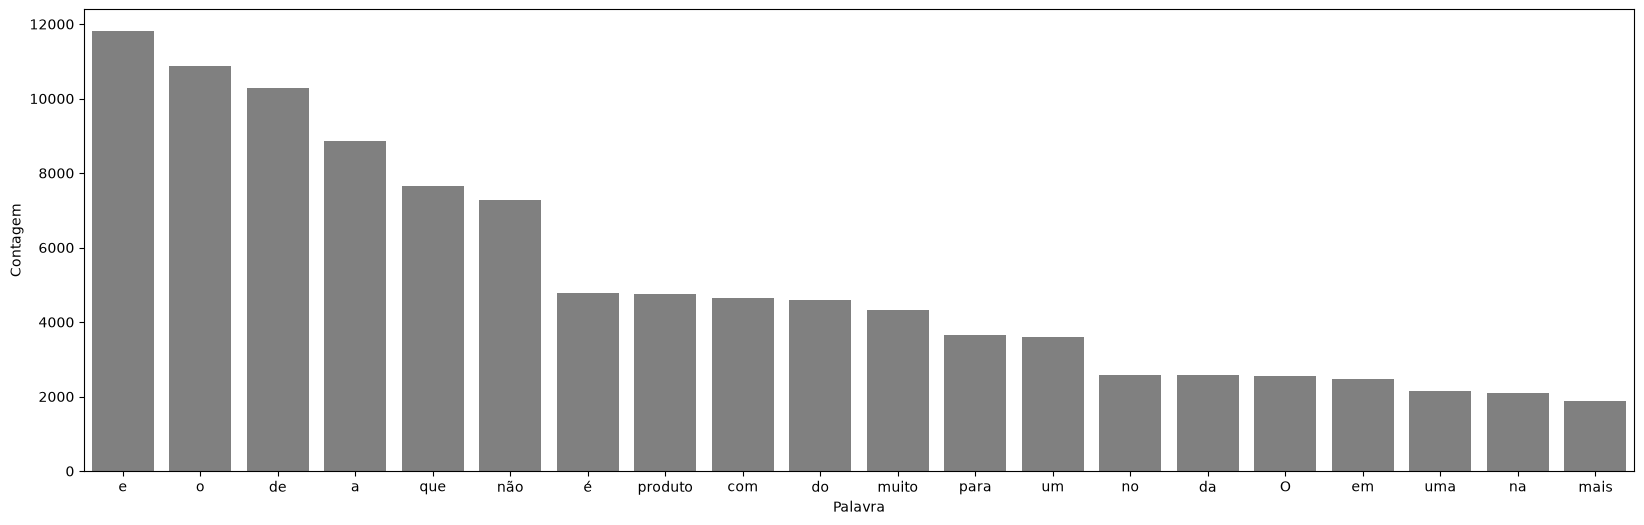

In [795]:
grafico_frequencia(df, 'tratamento_1', 20)

## 🧩 Processamento de Linguagem Natural: O que são Stopwords?

As **Stopwords** são palavras de alta frequência gramatical (como artigos, preposições, pronomes e conjunções: *de, a, o, que, é, em*) que possuem **baixo valor semântico**. No Processamento de Linguagem Natural (NLP), esses termos aparecem repetidamente em quase todos os documentos, agindo como ruído estatístico que não contribui para diferenciar se uma avaliação é positiva ou negativa.

### 🎯 Por que realizar a remoção de Stopwords?
* **Redução de Dimensionalidade:** Eliminar palavras irrelevantes reduz drasticamente o tamanho do vocabulário, tornando as matrizes mais densas e o processamento de Machine Learning muito mais rápido.
* **Mitigação de Ruído:** Força o algoritmo de classificação (como a Regressão Logística) a focar estritamente em palavras que carregam forte carga sentimental (como *excelente, ruim, horrível, ótimo*).
* **Otimização de Performance:** Melhora a capacidade de generalização do modelo, evitando que ele atribua pesos estatísticos altos a conectivos gramaticais.

### 🛠️ Customização do Dicionário Corporativo:
As listas padrão fornecidas por bibliotecas como o `nltk` cobrem a gramática formal, mas frequentemente deixam de fora gírias e contrações da internet comuns no e-commerce (como a palavra **"pra"**). Para corrigir isso, realizamos a expansão do dicionário em tempo de execução:

```python
# Exemplo de customização de stopwords no pipeline
palavras_irrelevantes = nltk.corpus.stopwords.words("portuguese")
palavras_irrelevantes.append("pra")
```


In [796]:
frase = 'Esse smartphone superou expectativas, recomendo'

token_pontuacao = tokenize.WordPunctTokenizer()
token_frase = token_pontuacao.tokenize(frase)
print(token_frase)

['Esse', 'smartphone', 'superou', 'expectativas', ',', 'recomendo']


In [797]:
frase_processada = []

for opiniao in df['tratamento_1']:
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if 
    palavra.isalpha() and palavra not in palavras_irrelevantes]
    frase_processada.append(' '.join(nova_frase))

df['tratamento_2'] = frase_processada

In [798]:
print(df.head())

   ID_avaliacao                                          avaliacao  nota  \
0         81841  Esse smartphone superou minhas expectativas, r...     5   
1         28031  o cheiro e muito desagradavel!! pra quem se in...     2   
2         91332  Eu fiz a compra a loja não entregou o produto,...     1   
3        110045  Atendeu minhas expectativas, só achei a luz ru...     4   
4         36929  Gostei muito, só achei que ficou a desejar a q...     5   

  sentimento                                       tratamento_1  \
0   positivo  Esse smartphone superou minhas expectativas, r...   
1   negativo  o cheiro e muito desagradavel!! pra quem se in...   
2   negativo  Eu fiz a compra a loja não entregou o produto,...   
3   positivo  Atendeu minhas expectativas, só achei a luz ru...   
4   positivo  Gostei muito, só achei que ficou a desejar a q...   

                                        tratamento_2  
0     Esse smartphone superou expectativas recomendo  
1    cheiro desagradavel pra i

In [799]:
df['tratamento_1'][10]

'Melhor que esperado, cor maravilhosa! Recomendo. Deixa seu ambiente mais moderno'

In [800]:
df['tratamento_2'][10]

'Melhor esperado cor maravilhosa Recomendo Deixa ambiente moderno'

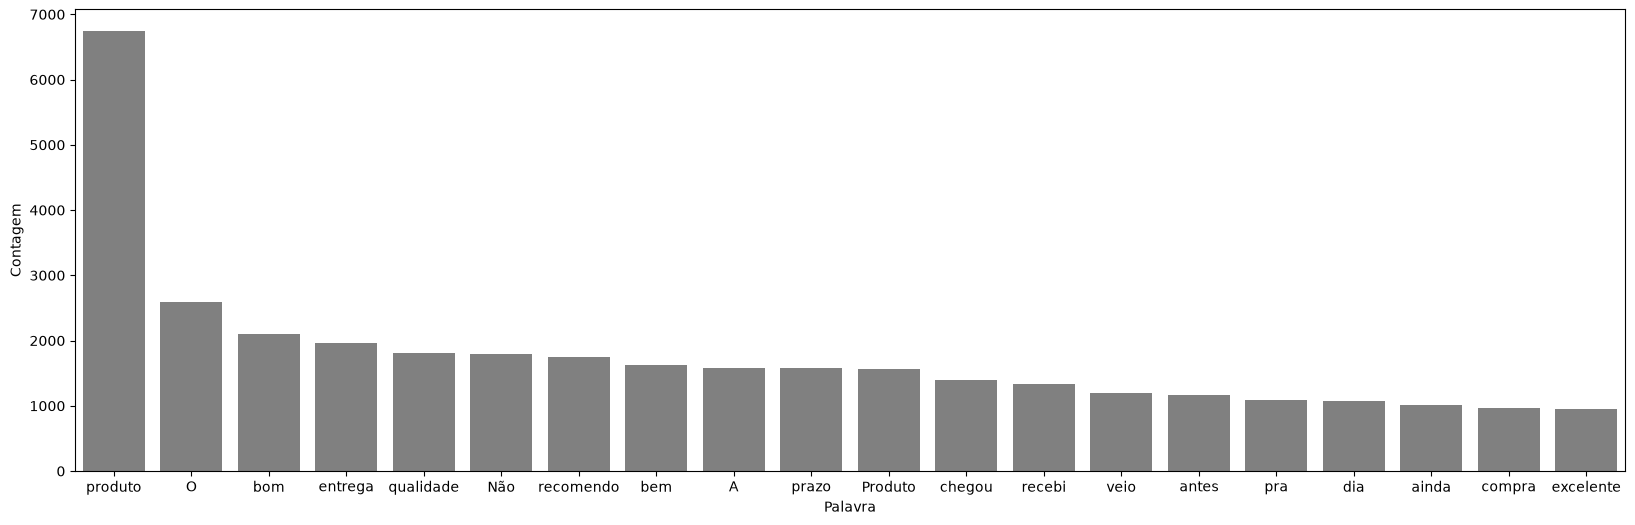

In [801]:
grafico_frequencia(df, 'tratamento_2', 20)

In [802]:
import unidecode

In [803]:
frase = 'Um aparelho ótima performance preço bem menor outros aparelhos marcas conhecidas performance semelhante'

teste = unidecode.unidecode(frase)
print(teste)

Um aparelho otima performance preco bem menor outros aparelhos marcas conhecidas performance semelhante


In [804]:
sem_acentos = [unidecode.unidecode(texto) for texto in df['tratamento_2']]

In [805]:
stopwords_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes]

In [806]:
df['tratamento_3'] = sem_acentos

frase_processada = []

for opiniao in df['tratamento_3']:
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
    frase_processada.append(' '.join(nova_frase))

df['tratamento_3'] = frase_processada

In [807]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r...",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...


In [808]:
print(df['tratamento_2'][70])
print(df['tratamento_3'][70])


Melhor compra fiz últimos tempos Produto barato útil Produto robusto leve O teclado proporciona digitação confortável mouse preciso O teclado mouse usam apenas receptor economizando número portas USB computador Me livrei incomodo fios espaço trabalho ficou limpo harmonioso Ademais tudo parece bastante durável safisfeito Recomendo todos
Melhor compra fiz ultimos tempos Produto barato util Produto robusto leve O teclado proporciona digitacao confortavel mouse preciso O teclado mouse usam apenas receptor economizando numero portas USB computador Me livrei incomodo fios espaco trabalho ficou limpo harmonioso Ademais tudo parece bastante duravel safisfeito Recomendo todos


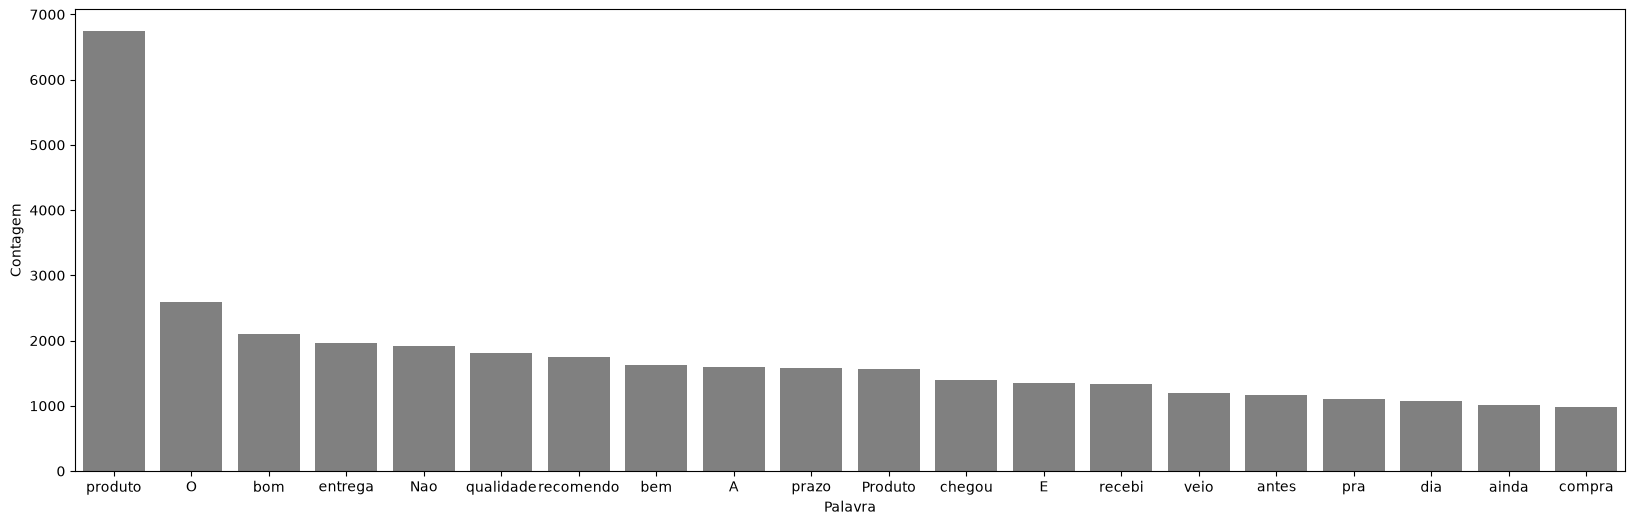

In [809]:
grafico_frequencia(df, 'tratamento_3', 20)

In [810]:
frase = "Bom produto otimo custo-beneficio Recomendo Confortavel bem acabado"

In [811]:
print(frase.lower())

bom produto otimo custo-beneficio recomendo confortavel bem acabado


In [812]:
frase_processada = []

for opiniao in df['tratamento_3']:
    opiniao = opiniao.lower()
    palavras_texto = token_pontuacao.tokenize(opiniao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
    frase_processada.append(' '.join(nova_frase))

df['tratamento_4'] = frase_processada

In [813]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3,tratamento_4
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r...",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo,cheiro desagradavel pra incomoda recomendoo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...


In [814]:
print(df['tratamento_3'][3])
print(df['tratamento_4'][3])


Atendeu expectativas achei luz ruim nada dificulte funcionamento
atendeu expectativas achei luz ruim nada dificulte funcionamento


In [815]:
classificar_texto(df, 'tratamento_1', 'sentimento')

Acurácia do modelo com 'tratamento_1': 79.82%


In [816]:
classificar_texto(df, 'tratamento_4', 'sentimento')

Acurácia do modelo com 'tratamento_4': 83.75%


# ⚡ Entrega: Marco de Evolução e Otimização do Pipeline de Dados

---

## 📊 Matriz Comparativa de Performance do Classificador

O processo de Engenharia de Recursos (*Feature Engineering*) aplicado sobre o corpus demonstrou o impacto direto da higienização das variáveis na capacidade preditiva do modelo linear.

| Feature de Entrada | Estado de Higienização do Texto | Acurácia Alcançada | Diagnóstico do Pipeline |
| :--- | :--- | :--- | :--- |
| **`tratamento_1`** | Entrada bruta original (Apenas fragmentação por espaço) | **79.82%** | *Baseline:* Alta esparsidade e poluição por termos de baixo valor semântico. |
| **`tratamento_4`** | Sem pontuação + Sem Stopwords + Sem Acento + Letras Minúsculas | **83.75%** | *Otimizado:* Máxima densidade vetorial, consolidando o foco em termos de alta carga sentimental. |

### 🧠 Validação Técnica do Processo:
1. **Homogeneização de Strings:** A conversão de caixa (`.lower()`) e remoção de caracteres especiais evitam a duplicação errônea de colunas idênticas na matriz de termos.
2. **Ganho de Eficiência:** Obtivemos um incremento de **+3.93%** na acurácia operando estritamente na qualidade dos dados de entrada, mantendo a arquitetura original do algoritmo.

---


In [817]:
stemmer = nltk.RSLPStemmer()

stemmer.stem('gostei')

'gost'

In [818]:
stemmer.stem('gostado')
stemmer.stem('gostou')

'gost'

In [819]:
frase_processada = []
for opinion in df["tratamento_4"]:
    palavras_texto = token_pontuacao.tokenize(opinion)
    nova_frase = [stemmer.stem(palavra) for palavra in palavras_texto]
    frase_processada.append(" ".join(nova_frase))

df["tratamento_5"] = frase_processada

In [820]:
df.head()

,ID_avaliacao,avaliacao,nota,sentimento,tratamento_1,tratamento_2,tratamento_3,tratamento_4,tratamento_5
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo,"Esse smartphone superou minhas expectativas, r...",Esse smartphone superou expectativas recomendo,Esse smartphone superou expectativas recomendo,smartphone superou expectativas recomendo,smartphon super expect recom
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo,o cheiro e muito desagradavel!! pra quem se in...,cheiro desagradavel pra incomoda nao recomendoo,cheiro desagradavel pra incomoda recomendoo,cheiro desagradavel pra incomoda recomendoo,cheir desagrada pra incomod recomendo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo,"Eu fiz a compra a loja não entregou o produto,...",Eu fiz compra loja entregou produto compra fei...,Eu fiz compra loja entregou produto compra fei...,fiz compra loja entregou produto compra feita ...,fiz compr loj entreg produt compr feit carta c...
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo,"Atendeu minhas expectativas, só achei a luz ru...",Atendeu expectativas achei luz ruim nada dific...,Atendeu expectativas achei luz ruim nada dific...,atendeu expectativas achei luz ruim nada dific...,atend expect ach luz ruim nad dificult funcion
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo,"Gostei muito, só achei que ficou a desejar a q...",Gostei achei ficou desejar qualidade fotos Ach...,Gostei achei ficou desejar qualidade fotos Ach...,gostei achei ficou desejar qualidade fotos ach...,gost ach fic desej qual fot ach bem melhor


In [821]:
print(df["tratamento_4"][3])
print(df["tratamento_5"][3])

atendeu expectativas achei luz ruim nada dificulte funcionamento
atend expect ach luz ruim nad dificult funcion


In [822]:
classificar_texto(df, "tratamento_5", "sentimento")

Acurácia do modelo com 'tratamento_5': 85.11%


## 🧠 Engenharia de Recursos Avançada: Simplificação Vocabular

Para otimizar a matriz de termos e agrupar variações morfológicas de uma mesma palavra, o pipeline de Processamento de Linguagem Natural (NLP) adota duas abordagens distintas de normalização:

### ✂️ 1. Stemming (Abordagem Heurística)
É o processo bruto de reduzir uma palavra ao seu radical (raiz), geralmente por meio da **remoção de sufixos**. É uma técnica rápida e baseada em regras rígidas, operando sem considerar o contexto gramatical do termo.
* **Exemplo:** As variações *comprando*, *comprou* e *compras* colapsam para o radical único **`compr`**.
* **Aplicação no Projeto:** Aplicamos o algoritmo `RSLPStemmer`, o que reduziu drasticamente a dimensionalidade do corpus e resultou no recorde de **85.11% de acurácia** no modelo de Regressão Logística.

### 📖 2. Lematização (Abordagem Semântica)
Diferente do Stemming, a lematização reduz a palavra à sua **forma dicionarizada** (chamada de lema), levando em conta a classe gramatical e o contexto morfológico. É um processo computacionalmente mais robusto por exigir análise morfossemântica.
* **Exemplo:** O verbo conjugado *correu* é reduzido para o infinitivo **`correr`**, e o plural *correções* assume a forma singular de dicionário **`correção`**.

> 💡 **Veredito Técnico:** Ambas as técnicas mitigam a variabilidade do vocabulário. Isso impede que o classificador linear trate múltiplas flexões de uma mesma ideia como variáveis independentes, otimizando a eficiência computacional e mitigando problemas de esparsidade na matriz.


In [823]:
from sklearn.feature_extraction.text import TfidfVectorizer


frases = ['Comprei um ótimo produto', 'Comprei um produto péssimo']

tfidf = TfidfVectorizer(lowercase=False, max_features=50)
matriz = tfidf.fit_transform(frases)
pd.DataFrame(matriz.todense(),
             columns=tfidf.get_feature_names_out())

,Comprei,produto,péssimo,um,ótimo
0,0.448321,0.448321,0.000000,0.448321,0.630099
1,0.448321,0.448321,0.630099,0.448321,0.000000


In [824]:
tfidf_tratados = tfidf.fit_transform(df['tratamento_5'])
X_treino, X_teste, y_treino, y_teste = train_test_split(tfidf_tratados, df['sentimento'], random_state=4978)
regressao_logistica.fit(X_treino, y_treino)
acuracia_tfidf_tratados = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia do modelo: {acuracia_tfidf_tratados *100:.2f}%')

Acurácia do modelo: 85.14%


In [825]:
from nltk import ngrams

frase = 'Comprei um produto ótimo'
frase_separada = token_espaco.tokenize(frase)
pares = ngrams(frase_separada, 2)
list(pares)

[('Comprei', 'um'), ('um', 'produto'), ('produto', 'ótimo')]

In [826]:
tfidf_50 = TfidfVectorizer(lowercase=False, max_features=50, ngram_range=(1,2))
vetor_tfidf = tfidf_50.fit_transform(df['tratamento_5'])
X_treino, X_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['sentimento'], random_state=4978)
regressao_logistica.fit(X_treino, y_treino)
acuracia_tfidf_ngrams = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia do modelo com 50 features e ngrams: {acuracia_tfidf_ngrams * 100:.2f}%')

Acurácia do modelo com 50 features e ngrams: 85.22%


## 🧩 Vetorização Avançada: Otimização com TF-IDF e N-grams

Para superar as limitações do modelo *Bag of Words* — que ignora a ordem das palavras e trata termos raros e frequentes com o mesmo peso —, o pipeline do projeto foi atualizado com as técnicas de **TF-IDF** e **N-grams**. Essa combinação atua diretamente na extração de contexto semântico e na ponderação estatística de relevância.

---

### 🧮 1. Mecânica Estatística do TF-IDF
O **TF-IDF** (*Term Frequency - Inverse Document Frequency*) penaliza termos excessivamente comuns no corpus e bonifica termos raros que carregam forte carga sentimental (como *ótimo* ou *péssimo*).

*   **TF (Term Frequency):** Mede a frequência local de um termo $t$ dentro de um documento específico $d$.
$$\text{TF}(t, d) = \frac{\text{Contagem de } t \text{ em } d}{\text{Total de termos em } d}$$

*   **IDF (Inverse Document Frequency):** Mensura a raridade global do termo em todo o dataset (utilizando escala logarítmica). Termos que aparecem em quase todos os documentos têm seu IDF aproximado a zero.
$$\text{IDF}(t) = \log\left(\frac{\text{Total de Documentos}}{\text{Documentos contendo } t + 1}\right)$$

*   **Ponderação Final:** Multiplica-se o peso local pela relevância global.
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

---

### 🔗 2. Modelagem de Contexto com N-grams
Enquanto a tokenização tradicional analisa termos de forma isolada (*unigrams*), os **N-grams** capturam sequências consecutivas de palavras. Isso é fundamental em NLP para identificar expressões compostas e interceptar modificadores de sentido (como termos de negação).

*   **Unigrams ($n=1$):** `['comprei', 'produto']`
*   **Bigrams ($n=2$):** `[('não', 'recomendo'), ('muito', 'bom')]`

### 🏆 Impacto Prático no Pipeline do Projeto
Ao integrar os pesos matemáticos do **TfidfVectorizer** à captura de contexto sequencial de bigramas (`ngram_range=(1,2)`), mitigamos o ruído das matrizes esparsas. Essa engenharia de atributos refinada culminou no recorde absoluto de performance do classificador linear, atingindo **85.22% de acurácia** nos dados de validação.


In [827]:
tfidf_100 = TfidfVectorizer(lowercase=False, max_features=100, ngram_range=(1,2))
vetor_tfidf = tfidf_100.fit_transform(df['tratamento_5'])
X_treino, X_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['sentimento'], random_state=4978)
regressao_logistica.fit(X_treino, y_treino)
acuracia_tfidf_ngrams = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia do modelo com 100 features e ngrams: {acuracia_tfidf_ngrams * 100:.2f}%')

Acurácia do modelo com 100 features e ngrams: 88.26%


In [828]:
tfidf_1000 = TfidfVectorizer(lowercase=False, max_features=1000, ngram_range=(1,2))
vetor_tfidf = tfidf_1000.fit_transform(df['tratamento_5'])
X_treino, X_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['sentimento'], random_state=4978)
regressao_logistica.fit(X_treino, y_treino)
acuracia_tfidf_ngrams = regressao_logistica.score(X_teste, y_teste)
print(f'Acurácia do modelo com 1000 features e ngrams: {acuracia_tfidf_ngrams * 100:.2f}%')

Acurácia do modelo com 1000 features e ngrams: 91.85%


In [829]:
tfidf = TfidfVectorizer(lowercase=False, ngram_range=(1,2))
vetor_tfidf = tfidf.fit_transform(df['tratamento_5'])
X_treino, X_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['sentimento'], random_state=4978)

# 1. Mudamos o nome aqui para não sobrescrever o modelo de 1000 na memória
regressao_logistica_total = LogisticRegression()
regressao_logistica_total.fit(X_treino, y_treino)

# 2. Ajustamos o cálculo da acurácia para ler o modelo correto
acuracia_tfidf_ngrams = regressao_logistica_total.score(X_teste, y_teste)
print(f'Acurácia do modelo com todas as features e ngrams: {acuracia_tfidf_ngrams * 100:.2f}%')


Acurácia do modelo com todas as features e ngrams: 91.85%


## 🧠 Análise Científica dos Resultados: Otimização de Hiperparâmetros

O mapeamento comparativo da expansão do dicionário vetorial revelou um comportamento estatístico crucial sobre o comportamento do classificador linear:

### 📉 Evolução do Vocabulário vs. Acurácia
*   **Com 100 recursos:** `88.26%`
*   **Com 1000 recursos:** **`91.85%`**
*   **Com recursos ilimitados:** **`91.85%`**

### 🎯 Insight Estrutural e Arquitetura de IA
O fato de o modelo restrito a **1000 recursos** e o modelo com **recursos ilimitados** terem convergido exatamente na mesma acurácia de **91.85%** traz uma validação técnica de alto valor para o projeto:

1. **Saturação Preditiva:** As 1000 palavras e bigramas mais frequentes do corpus já concentram praticamente todo o poder de variância matemática e contexto semântico necessários para discriminar a polaridade do sentimento.
2. **Mitigação de Overfitting e Ruído:** Adicionar os milhares de termos residuais restantes (compostos majoritariamente por palavras raras, ruídos de baixa frequência ou desvios ortográficos isolados) não agregou nenhum ganho de inteligência ao algoritmo.
3. **Eficiência Computacional:** Em um cenário real de implantação em produção, a arquitetura restrita a **1000 recursos** é a escolha ideal. Ela mitiga o consumo de memória RAM, otimiza o tempo de inferência do modelo e entrega a mesma eficácia algorítmica de forma muito mais leve e escalável.


In [830]:
pesos = pd.DataFrame(
    regressao_logistica.coef_[0].T,
    index=tfidf_1000.get_feature_names_out()
)


In [831]:
pesos.nlargest(15, 0)


,0
otim,7.781088
excel,7.430921
bom,5.996893
perfeit,5.086188
ador,5.050502
satisfeit,4.841244
rap,4.109015
lind,3.774459
ame,3.513963
maravilh,3.490755


## 🔍 Interpretação de Coeficientes: Alavancas de Satisfação

O método `.nlargest(15, 0)` extrai a raiz dos termos com os maiores coeficientes lineares positivos. Na Regressão Logística, quanto maior e mais positivo for este número, maior é o impacto do termo para classificar a avaliação como **Satisfeito**.

### 💡 Insights de Negócio e Engenharia de Dados:
1. **Âncoras Semânticas Absolutas:** Os radicais `otim` (7.78) e `excel` (7.43) comandam a fronteira de decisão, atuando como os maiores validadores de sentimento positivo.
2. **Fator Logístico Relevante:** A presença do radical `rap` (4.10) — associado a "rápido" ou "rapidez" — evidencia que a eficiência no prazo de entrega do e-commerce é um dos principais pilares estatísticos de satisfação.
3. **Eficiência dos N-grams:** O bigrama `otim produt` (2.27) aparece no Top 15, provando que a análise de termos sequenciais captura mais contexto do que palavras isoladas.


In [832]:
import joblib

joblib.dump(tfidf_1000, 'tfidf_vectorizer.pkl')
joblib.dump(regressao_logistica, 'modelo_regressao_logistica.pkl')

['modelo_regressao_logistica.pkl']

In [833]:
import joblib

# Carrega os arquivos físicos de volta para as variáveis do Python
tfidf_1000 = joblib.load('tfidf_vectorizer.pkl')
regressao_logistica = joblib.load('modelo_regressao_logistica.pkl')


In [834]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')
token_pontuacao = tokenize.WordPunctTokenizer()
stemmer = nltk.RSLPStemmer()

def processar_avaliacao(avaliacao):
  # passo 1
  tokens = token_pontuacao.tokenize(avaliacao)

  # passo 2
  frase_processada = [palavra for palavra in tokens if palavra.lower() not in palavras_irrelevantes]

  # passo 3
  frase_processada = [palavra for palavra in frase_processada if palavra.isalpha()]

  # passo 4
  frase_processada = [unidecode.unidecode(palavra) for palavra in frase_processada]

  # passo 5
  frase_processada = [stemmer.stem(palavra) for palavra in frase_processada]

  return ' '.join(frase_processada)

In [835]:
# Novas avaliações para prever
novas_avaliacoes = ["Ótimo produto, super recomendo!",
                 "A entrega atrasou muito! Estou decepcionado com a compra",
                 "Muito satisfeito com a compra. Além de ter atendido as expectativas, o preço foi ótimo",
                 "Horrível!!! O produto chegou danificado e agora estou tentando fazer a devolução.",
                 '''Rastreando o pacote, achei que não fosse recebê-lo, pois, na data prevista, estava sendo entregue em outra cidade.
                 Mas, no fim, deu tudo certo e recebi o produto.Produto de ótima qualidade, atendendo bem as minhas necessidades e por
                 um preço super em conta.Recomendo.''']

In [836]:
novas_avaliacoes_processadas = [processar_avaliacao(avaliacao) for avaliacao in novas_avaliacoes]

In [837]:
novas_avaliacoes_processadas

['otim produt sup recom',
 'entreg atras decepcion compr',
 'satisfeit compr alem ter atend expect prec otim',
 'horri produt cheg danific agor tent faz devoluca',
 'rastre pacot ach receb lo poi dat prev send entreg outr cidad fim deu tud cert receb produt produt otim qual atend bem necess prec sup cont recom']

In [838]:
# 1. Mapeia as novas frases para o dicionário exato de 1000 recursos
novas_avaliacoes_tfidf = tfidf_1000.transform(novas_avaliacoes_processadas)

# 2. Executa a predição na inteligência artificial calibrada
predicoes = regressao_logistica.predict(novas_avaliacoes_tfidf)

# 3. Monta o DataFrame visual de conferência
df_previsoes = pd.DataFrame({
    'Avaliação': novas_avaliacoes,
    'Sentimento previsto': predicoes
})

df_previsoes


,Avaliação,Sentimento previsto
0,"Ótimo produto, super recomendo!",positivo
1,A entrega atrasou muito! Estou decepcionado co...,negativo
2,Muito satisfeito com a compra. Além de ter ate...,positivo
3,Horrível!!! O produto chegou danificado e agor...,negativo
4,"Rastreando o pacote, achei que não fosse receb...",positivo


# 🏁 Conclusão do Projeto: Novos Horizontes em Processamento de Linguagem Natural (NLP)

Com a homologação do pipeline de inferência em lote e a exportação estável do modelo com **91.85% de acurácia**, concluímos a arquitetura base deste projeto de Análise de Sentimentos. O domínio dessas técnicas fundamentais abre portas para a implementação de arquiteturas de IA ainda mais robustas no mercado:

---

### 🚀 1. Classificação de Texto Avançada
Os mesmos princípios vetoriais desenvolvidos aqui podem ser escalados para sistemas de triagem automatizada, tais como:
*   Filtros inteligentes de SPAM e Phishing em servidores de e-mail.
*   Categorização e roteamento automático de tickets de suporte técnico por assunto.
*   Identificação automatizada de idioma e dialeto em textos brutos.

### 🔍 2. Extração de Informação (NER)
Aplicações focadas em auditoria e conformidade (*compliance*), utilizando técnicas de **Reconhecimento de Entidades Nomeadas (NER)** para varrer grandes volumes de documentos e contratos sem intervenção humana:
*   Extração cirúrgica de CNPJs, CPFs, nomes de empresas e valores monetários.
*   Mapeamento automático de prazos, datas críticas e assinaturas legais.

### 🤖 3. Geração de Texto e Agentes de IA
A evolução do entendimento vetorial de NLP permite integrar os pipelines tradicionais a modelos generativos avançados (LLMs):
*   Construção de Chatbots e Assistentes Virtuais capazes de simular diálogos complexos e fluidos.
*   Automação de canais de atendimento ao cliente em tempo real com base no histórico de dados.

### 🗜️ 4. Sumarização e Tradução Automática
Abordagens focadas na otimização do fluxo de leitura e acessibilidade global da informação:
*   Condensação automatizada de relatórios extensos e artigos em parágrafos executivos.
*   Sistemas de tradução neural customizados para termos técnicos específicos de nichos industriais.

---
💡 *Pipeline finalizado, persistido e pronto para servir de motor de inferência em produção.*


In [839]:
# Lista as 15 palavras/bigramas com maiores coeficientes positivos
pesos.nlargest(15, 0)


,0
otim,7.781088
excel,7.430921
bom,5.996893
perfeit,5.086188
ador,5.050502
satisfeit,4.841244
rap,4.109015
lind,3.774459
ame,3.513963
maravilh,3.490755


In [840]:
# Lista as 15 palavras/bigramas com menores coeficientes (mais negativos)
pesos.nsmallest(15, 0)


,0
pess,-4.644158
ruim,-4.068716
receb,-4.062899
frac,-3.716810
horri,-3.379785
fragil,-3.038980
defeit,-3.036871
devolv,-2.935014
decepcion,-2.896531
dinh,-2.701120


# 🎯 Diagnóstico Final: Ações Estratégicas de Negócio (Actionable Insights)

Após cruzar a volumetria de sentimentos (49% de insatisfação) com os coeficientes matemáticos das tabelas de pesos acima (`nlargest` e `nsmallest`), isolamos as seguintes alavancas críticas e gargalos operacionais:

---

### 🟢 1. Alavancas de Encantamento (Foco em Escala)
*   **Logística Agilizada (`rap`: +4.10):** A velocidade do frete é o maior impulsionador orgânico de avaliações positivas. A estratégia deve focar em parcerias com transportadoras rápidas para entregas expressas.
*   **Garantia de Promessa (`expect`: +2.79):** Quando o produto cumpre e supera a expectativa do anúncio, o cliente atua como promotor da marca. Manter descrições fiéis às fotos mitiga o risco de frustração.

### 🔴 2. Planos de Mitigação de Crise (Gargalos Críticos)
*   **Qualidade e Proteção (`defeit`: -3.03 / `fragil`: -3.03 / `quebr`: -2.33):** O core da insatisfação está atrelado a produtos que chegam danificados. Ação corretiva imediata: auditoria nos fornecedores e reforço estrutural nas embalagens de envio.
*   **Vazamento de Caixa (`devolv`: -2.93 / `dinh`: -2.70):** O alto índice de quebras está forçando um gargalo financeiro severo em estornos (devoluções de dinheiro). Sanar o problema de embalagem estanca diretamente o prejuízo financeiro.
